In [2]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 9.6 MB/s eta 0:00:009.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 7.6 MB/s eta 0:00:00m eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]━━━ 1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load WDBC dataset
data = pd.read_csv("wdbc.data", header=None)

# Create column names
columns = ["ID", "Diagnosis"] + [f"Feature_{i}" for i in range(1, 31)]
data.columns = columns

print("Dataset Shape:", data.shape)
print(data.head())

Dataset Shape: (569, 32)
         ID Diagnosis  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  \
0    842302         M      17.99      10.38     122.80     1001.0    0.11840   
1    842517         M      20.57      17.77     132.90     1326.0    0.08474   
2  84300903         M      19.69      21.25     130.00     1203.0    0.10960   
3  84348301         M      11.42      20.38      77.58      386.1    0.14250   
4  84358402         M      20.29      14.34     135.10     1297.0    0.10030   

   Feature_6  Feature_7  Feature_8  ...  Feature_21  Feature_22  Feature_23  \
0    0.27760     0.3001    0.14710  ...       25.38       17.33      184.60   
1    0.07864     0.0869    0.07017  ...       24.99       23.41      158.80   
2    0.15990     0.1974    0.12790  ...       23.57       25.53      152.50   
3    0.28390     0.2414    0.10520  ...       14.91       26.50       98.87   
4    0.13280     0.1980    0.10430  ...       22.54       16.67      152.20   

   Feature_24  Feat

In [6]:
# Convert target:
# M = 1 (Malignant)
# B = 0 (Benign)

data["Diagnosis"] = data["Diagnosis"].map({
    "M": 1,
    "B": 0
})

# Remove ID
X = data.drop(columns=["ID", "Diagnosis"])
y = data["Diagnosis"]

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nClass Distribution:")
print(y.value_counts())

print("\nMissing Values:", X.isnull().sum().sum())

Number of samples: 569
Number of features: 30

Class Distribution:
Diagnosis
0    357
1    212
Name: count, dtype: int64

Missing Values: 0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


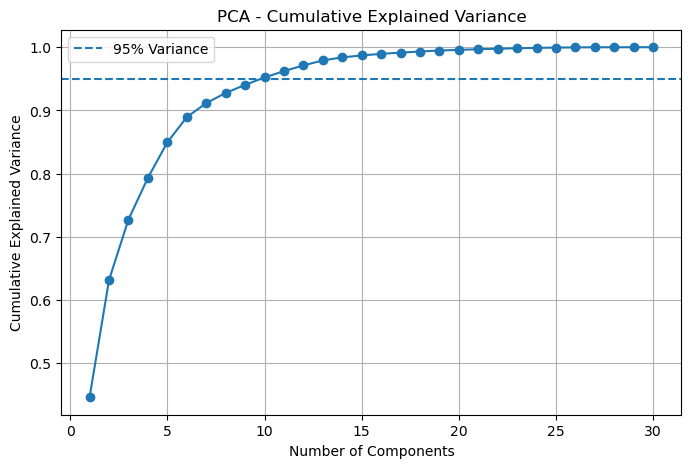

In [8]:
# Standardize data before PCA
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_train)

# PCA with all components
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid()
plt.show()

In [9]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Components required for 95% variance:", n_components)

print(
    "Explained variance:",
    cumulative_variance[n_components - 1] * 100,
    "%"
)

Components required for 95% variance: 10
Explained variance: 95.20691014391002 %


In [10]:
models = {

    "SVM": SVC(probability=True, random_state=42),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

In [11]:
stacking_model = StackingClassifier(
    estimators=[
        (
            "svm",
            SVC(
                probability=True,
                random_state=42
            )
        ),
        (
            "nb",
            GaussianNB()
        ),
        (
            "dt",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ],
    final_estimator=LogisticRegression(
        max_iter=2000
    ),
    cv=5
)

models["Stacking"] = stacking_model

In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [13]:
def create_pipeline(model, use_pca=False):

    if use_pca:

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", model)
        ])

    else:

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

    return pipeline

In [15]:
param_grids = {

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

    "Naive Bayes": {
        "model__var_smoothing": [1e-9, 1e-8, 1e-7]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    },

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10]
    },

    "Decision Tree": {
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 5, 10]
    },

    "Random Forest": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [None, 5, 10],
        "model__max_features": ["sqrt", "log2"]
    },

    "AdaBoost": {
        "model__n_estimators": [50, 100],
        "model__learning_rate": [0.01, 0.1, 1]
    },

    "Gradient Boosting": {
        "model__n_estimators": [50, 100],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },

    "XGBoost": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [2, 3],
        "model__learning_rate": [0.05, 0.1]
    },

    "Stacking": {
        "model__final_estimator__C": [0.1, 1, 10]
    }
}

print("Hyperparameter grids loaded successfully!")

Hyperparameter grids loaded successfully!


In [16]:
best_models = {}
cv_results = []

for name, model in models.items():

    print("\n" + "=" * 60)
    print("MODEL:", name)
    print("=" * 60)

    for setting in ["No-PCA", "With-PCA"]:

        print("\nRunning:", setting)

        use_pca = setting == "With-PCA"

        pipeline = create_pipeline(
            model,
            use_pca
        )

        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            cv=cv,
            scoring="accuracy",
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        best_models[(name, setting)] = grid.best_estimator_

        # Get five CV fold scores using best model
        fold_scores = cross_val_score(
            grid.best_estimator_,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1
        )

        print("Best Parameters:", grid.best_params_)
        print("Fold Scores:", fold_scores)
        print("Average Accuracy:", fold_scores.mean())

        cv_results.append({
            "Model": name,
            "Setting": setting,
            "Fold 1": fold_scores[0],
            "Fold 2": fold_scores[1],
            "Fold 3": fold_scores[2],
            "Fold 4": fold_scores[3],
            "Fold 5": fold_scores[4],
            "Average Accuracy": fold_scores.mean(),
            "Std Dev": fold_scores.std()
        })


MODEL: SVM

Running: No-PCA
Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Fold Scores: [0.96703297 0.98901099 0.96703297 0.97802198 0.97802198]
Average Accuracy: 0.9758241758241759

Running: With-PCA
Best Parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Fold Scores: [0.96703297 0.96703297 0.96703297 0.97802198 0.98901099]
Average Accuracy: 0.9736263736263737

MODEL: Naive Bayes

Running: No-PCA
Best Parameters: {'model__var_smoothing': 1e-09}
Fold Scores: [0.95604396 0.97802198 0.91208791 0.91208791 0.93406593]
Average Accuracy: 0.9384615384615385

Running: With-PCA
Best Parameters: {'model__var_smoothing': 1e-09}
Fold Scores: [0.91208791 0.97802198 0.89010989 0.87912088 0.92307692]
Average Accuracy: 0.9164835164835164

MODEL: KNN

Running: No-PCA
Best Parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'uniform'}
Fold Scores: [0.96703297 1.         0.96703297 0.95604396 0.98901099]

In [17]:
cv_df = pd.DataFrame(cv_results)

print(
    cv_df.to_string(index=False)
)

              Model  Setting   Fold 1   Fold 2   Fold 3   Fold 4   Fold 5  Average Accuracy  Std Dev
                SVM   No-PCA 0.967033 0.989011 0.967033 0.978022 0.978022          0.975824 0.008223
                SVM With-PCA 0.967033 0.967033 0.967033 0.978022 0.989011          0.973626 0.008791
        Naive Bayes   No-PCA 0.956044 0.978022 0.912088 0.912088 0.934066          0.938462 0.025631
        Naive Bayes With-PCA 0.912088 0.978022 0.890110 0.879121 0.923077          0.916484 0.034471
                KNN   No-PCA 0.967033 1.000000 0.967033 0.956044 0.989011          0.975824 0.016150
                KNN With-PCA 0.978022 0.978022 0.956044 0.956044 0.989011          0.971429 0.013187
Logistic Regression   No-PCA 0.956044 0.967033 1.000000 0.978022 0.967033          0.973626 0.014906
Logistic Regression With-PCA 0.956044 0.956044 1.000000 0.978022 0.989011          0.975824 0.017582
      Decision Tree   No-PCA 0.890110 0.967033 0.890110 0.912088 0.956044          0.923077

In [18]:
comparison = cv_df.pivot(
    index="Model",
    columns="Setting",
    values="Average Accuracy"
)

print("\nAverage CV Accuracy Comparison:")
print(comparison.round(4))


Average CV Accuracy Comparison:
Setting              No-PCA  With-PCA
Model                                
AdaBoost             0.9670    0.9714
Decision Tree        0.9231    0.9341
Gradient Boosting    0.9670    0.9516
KNN                  0.9758    0.9714
Logistic Regression  0.9736    0.9758
Naive Bayes          0.9385    0.9165
Random Forest        0.9670    0.9538
SVM                  0.9758    0.9736
Stacking             0.9736    0.9714
XGBoost              0.9714    0.9648


In [19]:
comparison["Improvement (%)"] = (
    comparison["With-PCA"]
    -
    comparison["No-PCA"]
) * 100

print(
    comparison.round(4)
)

Setting              No-PCA  With-PCA  Improvement (%)
Model                                                 
AdaBoost             0.9670    0.9714           0.4396
Decision Tree        0.9231    0.9341           1.0989
Gradient Boosting    0.9670    0.9516          -1.5385
KNN                  0.9758    0.9714          -0.4396
Logistic Regression  0.9736    0.9758           0.2198
Naive Bayes          0.9385    0.9165          -2.1978
Random Forest        0.9670    0.9538          -1.3187
SVM                  0.9758    0.9736          -0.2198
Stacking             0.9736    0.9714          -0.2198
XGBoost              0.9714    0.9648          -0.6593


In [20]:
test_results = []

for name in models.keys():

    for setting in ["No-PCA", "With-PCA"]:

        model = best_models[(name, setting)]

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        precision = precision_score(
            y_test,
            y_pred
        )

        recall = recall_score(
            y_test,
            y_pred
        )

        f1 = f1_score(
            y_test,
            y_pred
        )

        test_results.append({
            "Model": name,
            "Setting": setting,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })

test_df = pd.DataFrame(test_results)

print(
    test_df.round(4).to_string(index=False)
)

              Model  Setting  Accuracy  Precision  Recall  F1 Score
                SVM   No-PCA    0.9737     1.0000  0.9286    0.9630
                SVM With-PCA    0.9825     1.0000  0.9524    0.9756
        Naive Bayes   No-PCA    0.9211     0.9231  0.8571    0.8889
        Naive Bayes With-PCA    0.8947     0.8571  0.8571    0.8571
                KNN   No-PCA    0.9649     1.0000  0.9048    0.9500
                KNN With-PCA    0.9474     0.9737  0.8810    0.9250
Logistic Regression   No-PCA    0.9649     0.9750  0.9286    0.9512
Logistic Regression With-PCA    0.9737     1.0000  0.9286    0.9630
      Decision Tree   No-PCA    0.9298     0.9048  0.9048    0.9048
      Decision Tree With-PCA    0.9386     0.9487  0.8810    0.9136
      Random Forest   No-PCA    0.9737     1.0000  0.9286    0.9630
      Random Forest With-PCA    0.9386     0.9268  0.9048    0.9157
           AdaBoost   No-PCA    0.9825     1.0000  0.9524    0.9756
           AdaBoost With-PCA    0.9649     0.975

In [21]:
accuracy_comparison = test_df.pivot(
    index="Model",
    columns="Setting",
    values="Accuracy"
)

f1_comparison = test_df.pivot(
    index="Model",
    columns="Setting",
    values="F1 Score"
)

print("ACCURACY")
print(accuracy_comparison.round(4))

print("\nF1 SCORE")
print(f1_comparison.round(4))

ACCURACY
Setting              No-PCA  With-PCA
Model                                
AdaBoost             0.9825    0.9649
Decision Tree        0.9298    0.9386
Gradient Boosting    0.9649    0.9561
KNN                  0.9649    0.9474
Logistic Regression  0.9649    0.9737
Naive Bayes          0.9211    0.8947
Random Forest        0.9737    0.9386
SVM                  0.9737    0.9825
Stacking             0.9825    0.9737
XGBoost              0.9649    0.9649

F1 SCORE
Setting              No-PCA  With-PCA
Model                                
AdaBoost             0.9756    0.9512
Decision Tree        0.9048    0.9136
Gradient Boosting    0.9500    0.9383
KNN                  0.9500    0.9250
Logistic Regression  0.9512    0.9630
Naive Bayes          0.8889    0.8571
Random Forest        0.9630    0.9157
SVM                  0.9630    0.9756
Stacking             0.9756    0.9630
XGBoost              0.9500    0.9512


In [22]:
# Find best model for No-PCA
best_no_pca = test_df[
    test_df["Setting"] == "No-PCA"
].sort_values(
    "Accuracy",
    ascending=False
).iloc[0]

# Find best model for PCA
best_pca = test_df[
    test_df["Setting"] == "With-PCA"
].sort_values(
    "Accuracy",
    ascending=False
).iloc[0]

print("Best No-PCA model:")
print(best_no_pca)

print("\nBest With-PCA model:")
print(best_pca)

Best No-PCA model:
Model        AdaBoost
Setting        No-PCA
Accuracy     0.982456
Precision         1.0
Recall       0.952381
F1 Score      0.97561
Name: 12, dtype: object

Best With-PCA model:
Model             SVM
Setting      With-PCA
Accuracy     0.982456
Precision         1.0
Recall       0.952381
F1 Score      0.97561
Name: 1, dtype: object


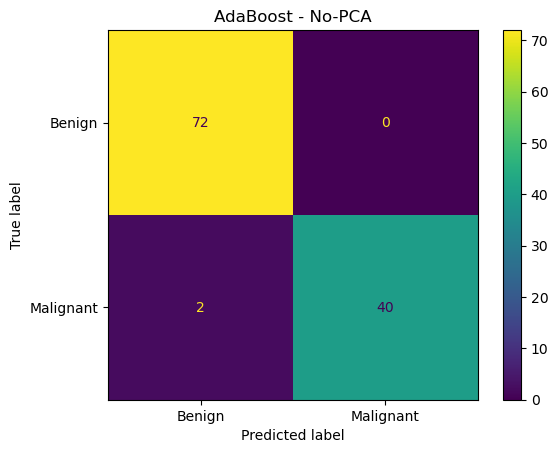

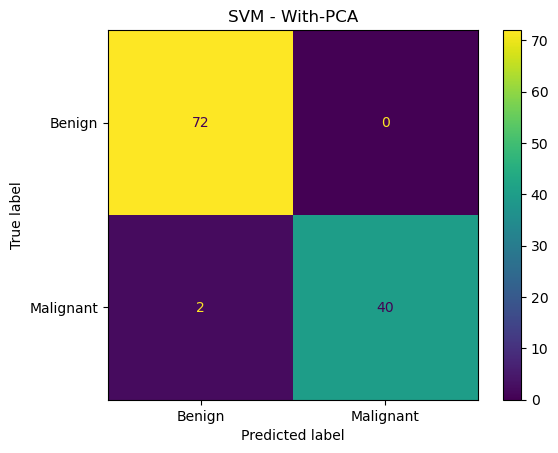

In [23]:
selected_models = [
    (
        best_no_pca["Model"],
        "No-PCA"
    ),
    (
        best_pca["Model"],
        "With-PCA"
    )
]

for name, setting in selected_models:

    model = best_models[(name, setting)]

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )

    disp.plot()

    plt.title(
        f"{name} - {setting}"
    )

    plt.show()

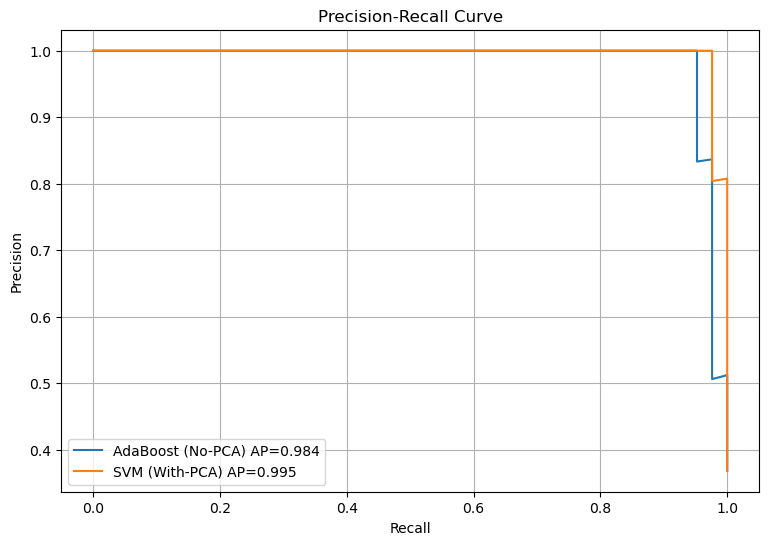

In [24]:
plt.figure(figsize=(9, 6))

for name, setting in selected_models:

    model = best_models[(name, setting)]

    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    ap = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} ({setting}) AP={ap:.3f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve"
)

plt.legend()
plt.grid()

plt.show()

In [25]:
final_table = test_df.copy()

final_table["Accuracy (%)"] = (
    final_table["Accuracy"] * 100
)

final_table["Precision (%)"] = (
    final_table["Precision"] * 100
)

final_table["Recall (%)"] = (
    final_table["Recall"] * 100
)

final_table["F1 Score (%)"] = (
    final_table["F1 Score"] * 100
)

final_table = final_table[
    [
        "Model",
        "Setting",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)"
    ]
]

print(
    final_table.round(2).to_string(index=False)
)

              Model  Setting  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
                SVM   No-PCA         97.37         100.00       92.86         96.30
                SVM With-PCA         98.25         100.00       95.24         97.56
        Naive Bayes   No-PCA         92.11          92.31       85.71         88.89
        Naive Bayes With-PCA         89.47          85.71       85.71         85.71
                KNN   No-PCA         96.49         100.00       90.48         95.00
                KNN With-PCA         94.74          97.37       88.10         92.50
Logistic Regression   No-PCA         96.49          97.50       92.86         95.12
Logistic Regression With-PCA         97.37         100.00       92.86         96.30
      Decision Tree   No-PCA         92.98          90.48       90.48         90.48
      Decision Tree With-PCA         93.86          94.87       88.10         91.36
      Random Forest   No-PCA         97.37         100.00       92.86       

Exception ignored in: <function ResourceTracker.__del__ at 0x784c83f88d60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f53bff88d60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x73197e590d60>
Traceback (most recent 